In [140]:
import ROOT as r 
import pandas as pd 
import mplhep as hep 
hep.style.use("LHCb2")
def get_dfs():
    df_base = r.RDataFrame("ntuple", "outputs/u2_baseline.root")
    df_uli  = r.RDataFrame("ntuple", "outputs/u2_uli_bsmumu.root")
    df_debug = r.RDataFrame("ntuple", "outputs/debug_baseline_bsmumu.root")
    dfs = {
        "baseline" :pd.DataFrame(df_base.AsNumpy()),
        "uli" : pd.DataFrame(df_uli.AsNumpy()),
        "debug" : pd.DataFrame(df_debug.AsNumpy())
    }
    return dfs
dfs = get_dfs()


states_ordered = [ "EndVelo", "BegRich1", "MidRich1", "EndRich1", "EndUT", "BegT","EndT",   "BegRich2", "EndRich2" ]

z_states   = [f"z_{s}" for s in states_ordered]
mat_states = [ f"fwd_integrated_matbudget_{s}" for s in states_ordered ]

for df_type in [ "debug", "baseline", "uli"]:
    dfs[df_type][f"fwd_integrated_matbudget_InT"] = dfs[df_type][f"fwd_integrated_matbudget_EndT"] - dfs[df_type][f"fwd_integrated_matbudget_BegT"]

# col = "fwd_integrated_matbudget_InT"
# low, high = 0, 100
# bins = 60
# plt.figure(figsize=(20, 6))

# for name, color in [("debug", "tab:red"), ("baseline", "tab:blue"), ("uli", "tab:green")]:
#     values = dfs[name][col]
#     values = values[(values >= low) & (values <= high)]
#     plt.hist(values, bins=bins, range=(low, high), histtype="step", linewidth=2, label=f"{name} (n={len(values)})", color=color, density=True)
# plt.yscale('log')
# plt.title(f"Comparison of {col} in [{low}, {high}]")
# plt.xlabel(col)
# plt.ylabel("Entries")
# plt.legend()
# plt.grid(alpha=0.25)
# plt.tight_layout()
# plt.show()
    

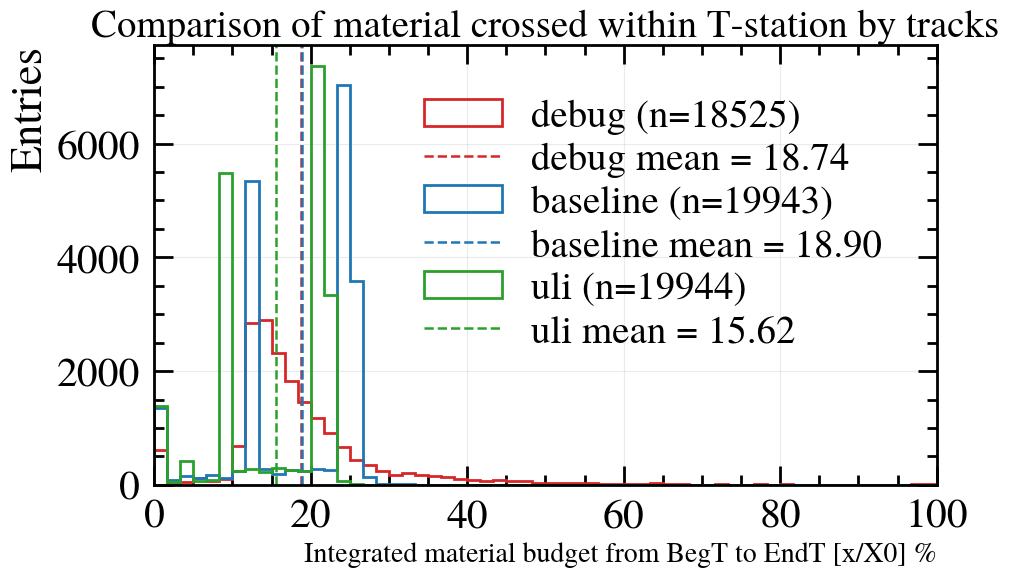

In [145]:
import matplotlib.pyplot as plt

col = "fwd_integrated_matbudget_InT"
low, high = 0, 100
bins = 60

plt.figure(figsize=(10, 6))

for name, color in [("debug", "tab:red"), ("baseline", "tab:blue"), ("uli", "tab:green")]:
    values = dfs[name][col]
    values = values[(values >= low) & (values <= high)]

    plt.hist(
        values,
        bins=bins,
        range=(low, high),
        histtype="step",
        linewidth=2,
        label=f"{name} (n={len(values)})",
        color=color,
    )

    mean_value = values.mean()
    plt.axvline(
        mean_value,
        color=color,
        linestyle="--",
        linewidth=1.8,
        label=f"{name} mean = {mean_value:.2f}",
    )

plt.title(f"Comparison of material crossed within T-station by tracks")
plt.xlabel("Integrated material budget from BegT to EndT [x/X0] %", fontsize=20)
plt.ylabel("Entries")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

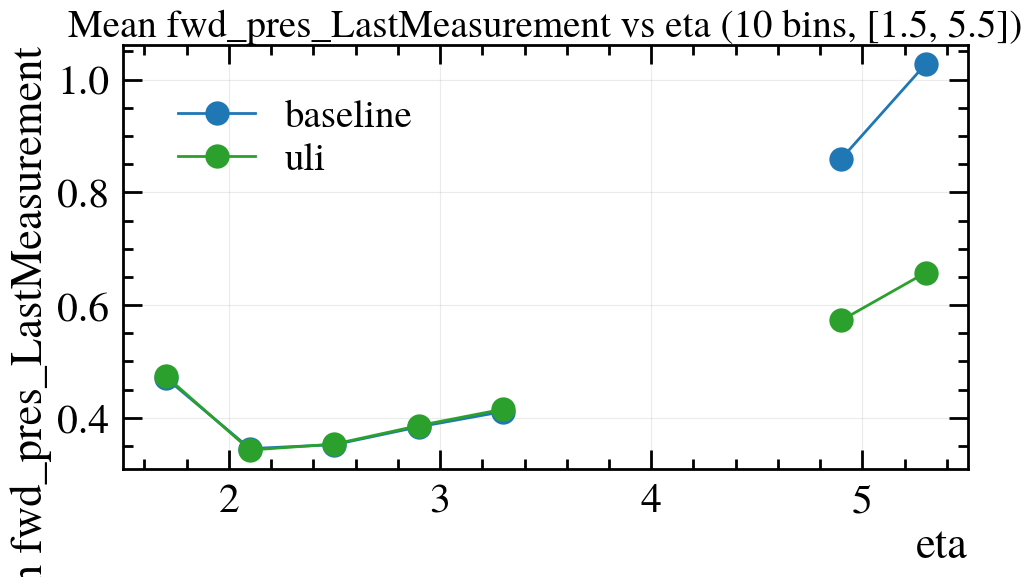

In [96]:
import numpy as np
import matplotlib.pyplot as plt

eta_min, eta_max = 1.5, 5.5
n_bins = 10
eta_bins = np.linspace(eta_min, eta_max, n_bins + 1)
eta_centers = 0.5 * (eta_bins[:-1] + eta_bins[1:])

selection = "(nVelo >= 3) & ((nFT >= 10) | (nMP >= 3)) & abs(100*fwd_pres_LastMeasurement)<5"
y_col = "fwd_pres_LastMeasurement"

plt.figure(figsize=(10, 6))

def get_dfs():
    df_base = r.RDataFrame("ntuple", "outputs/u2_baseline.root")
    df_uli  = r.RDataFrame("ntuple", "outputs/u2_uli_bsmumu.root")
    df_debug = r.RDataFrame("ntuple", "outputs/debug_baseline_bsmumu.root")
    dfs = {
        "baseline" :pd.DataFrame(df_base.AsNumpy()),
        "uli" : pd.DataFrame(df_uli.AsNumpy()),
        "debug" : pd.DataFrame(df_debug.AsNumpy())
    }
    return dfs
dfs = get_dfs()

for name, color in [("baseline", "tab:blue"), ("uli", "tab:green")]:
    df_sel = dfs[name].query(selection).copy()    
    df_sel["eta_bin"] = pd.cut(df_sel["eta"], bins=eta_bins, include_lowest=True, right=False)
    
    import numpy as np 
    df_sel["p_res"] = np.abs(df_sel[y_col]*100)
    mean_per_bin = (
        df_sel.groupby("eta_bin", observed=True)['p_res']
        .mean()
        .reindex(pd.IntervalIndex.from_breaks(eta_bins, closed="left"))
    )

    plt.plot(
        eta_centers,
        mean_per_bin.values,
        marker="o",
        linewidth=2,
        label=name,
        color=color,
    )

plt.title(f"Mean {y_col} vs eta (10 bins, [{eta_min}, {eta_max}])")
plt.xlabel("eta")
plt.ylabel(f"Mean {y_col}")
plt.xlim(eta_min, eta_max)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [97]:
# Check NaN presence in each dataframe and list columns that contain NaNs
for name in ["debug", "baseline", "uli"]:
    nan_counts = dfs[name].isna().sum()
    nan_cols = nan_counts[nan_counts > 0].sort_values(ascending=False)
    print(f"\n=== {name} ===")
    if nan_cols.empty:
        print("No NaNs found in any column.")
    else:
        print(f"Columns with NaNs: {len(nan_cols)}")
        print(nan_cols)
        print(f"Total NaN entries: {int(nan_cols.sum())}")


=== debug ===
No NaNs found in any column.

=== baseline ===
No NaNs found in any column.

=== uli ===
No NaNs found in any column.



baseline counts per eta bin [1.5, 5.5] with 10 bins:
[ 734 2569 2877 2870 2669 2207 1833 1203  379    8]
No empty eta bins.

uli counts per eta bin [1.5, 5.5] with 10 bins:
[ 697 2518 2891 2926 2713 2313 1837 1121  191    5]
No empty eta bins.


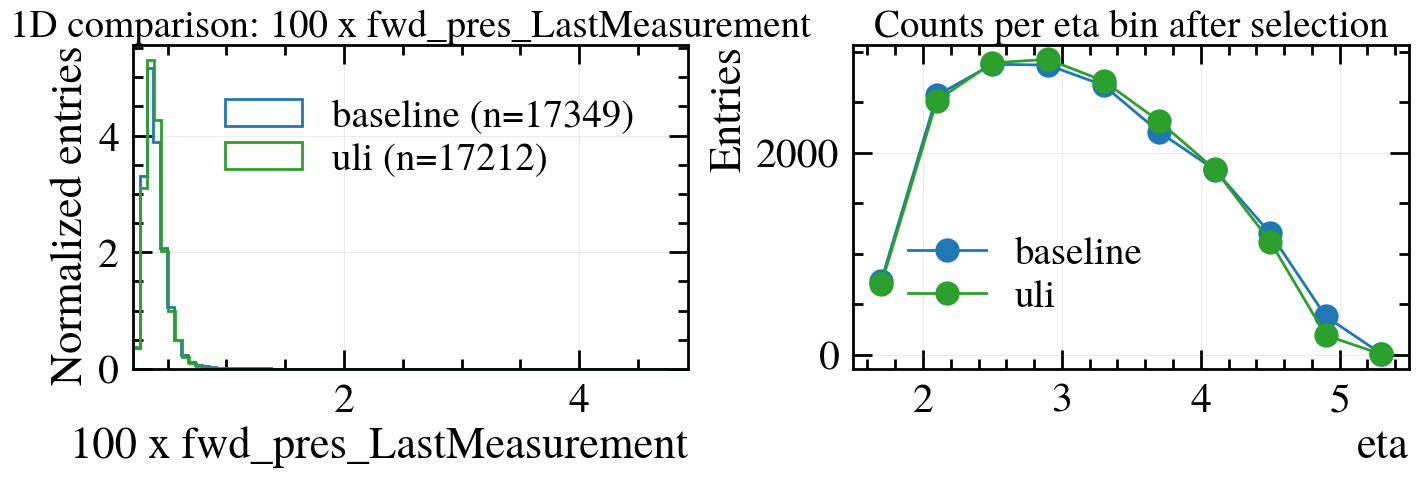

In [98]:
import numpy as np
import matplotlib.pyplot as plt

# Reuse the same selection and eta binning as the eta-mean plot
eta_edges = np.linspace(eta_min, eta_max, n_bins + 1)
plot_col = "fwd_pres_LastMeasurement"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, color in [("baseline", "tab:blue"), ("uli", "tab:green")]:
    df_sel = dfs[name].query(selection).copy()

    # 1D comparison of the variable used in the eta plot
    ax1.hist(
        100.0 * df_sel[plot_col],
        bins=80,
        histtype="step",
        linewidth=2,
        density=True,
        label=f"{name} (n={len(df_sel)})",
        color=color,
    )

    # Event counts per eta bin to diagnose empty bins
    counts, _ = np.histogram(df_sel["eta"], bins=eta_edges)
    eta_centers_local = 0.5 * (eta_edges[:-1] + eta_edges[1:])
    ax2.plot(eta_centers_local, counts, marker="o", linewidth=2, label=name, color=color)

    empty_bins = np.where(counts == 0)[0]
    print(f"\n{name} counts per eta bin [{eta_min}, {eta_max}] with {n_bins} bins:")
    print(counts)
    if len(empty_bins) == 0:
        print("No empty eta bins.")
    else:
        print("Empty eta bins (1-based):", (empty_bins + 1).tolist())

ax1.set_title("1D comparison: 100 x fwd_pres_LastMeasurement")
ax1.set_xlabel("100 x fwd_pres_LastMeasurement")
ax1.set_ylabel("Normalized entries")
ax1.grid(alpha=0.25)
ax1.legend()

ax2.set_title("Counts per eta bin after selection")
ax2.set_xlabel("eta")
ax2.set_ylabel("Entries")
ax2.set_xlim(eta_min, eta_max)
ax2.grid(alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()

baseline: non-empty profile bins = 15/15
uli: non-empty profile bins = 15/15


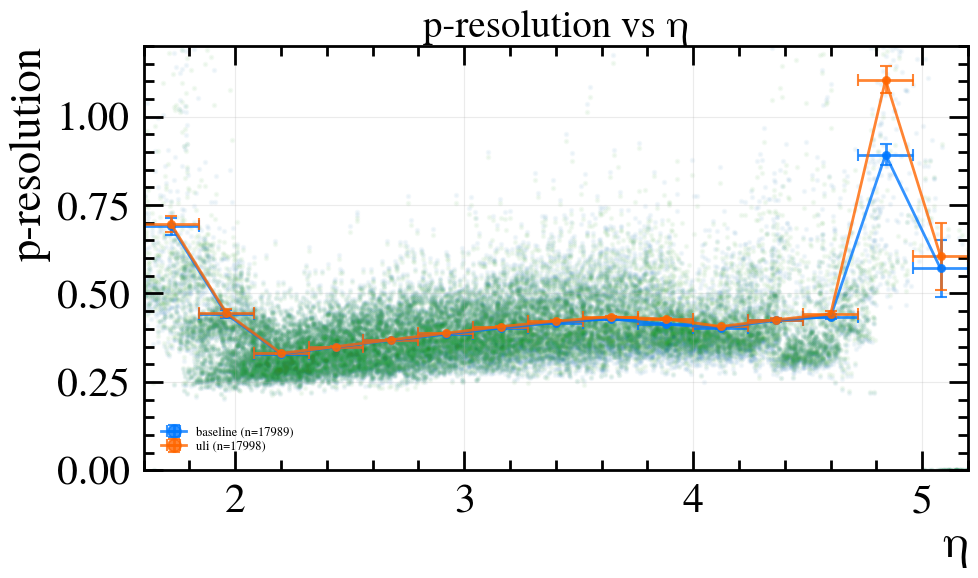

In [161]:
import numpy as np
import matplotlib.pyplot as plt

x_col = "eta"
y_col = "fwd_pres_LastMeasurement"

x_min, x_max = 1.6, 5.2
y_min, y_max = 0.0, 4.0
profile_n_bins = 15
profile_edges = np.linspace(x_min, x_max, profile_n_bins + 1)
profile_centers = 0.5 * (profile_edges[:-1] + profile_edges[1:])
profile_bin_widths = (profile_edges[1:] - profile_edges[:-1]) / 2.0  # Half-width for xerr

plt.figure(figsize=(10, 6))

for name, color in [("baseline", "tab:blue"), ("uli", "tab:green")]:
    df_sel = dfs[name].copy()
    df_sel["y_plot"] = 100.0 * df_sel[y_col]

    # Enforce finite values and explicit plotting range
    mask = (
        np.isfinite(df_sel[x_col])
        & np.isfinite(df_sel["y_plot"])
        & (df_sel[x_col] >= x_min)
        & (df_sel[x_col] <= x_max)
        & (df_sel["y_plot"] >= y_min)
        & (df_sel["y_plot"] < y_max)
    )
    df_sel = df_sel[mask]

    # Plot underlying scatter with low alpha
    plt.scatter(
        df_sel[x_col],
        df_sel["y_plot"],
        s=4,
        alpha=0.05,
        color=color,
        rasterized=True,
    )

    # Profiled mean with explicit bin counting to avoid IntervalIndex NaN artifacts.
    x_vals = df_sel[x_col].to_numpy()
    y_vals = df_sel["y_plot"].to_numpy()
    bin_idx = np.digitize(x_vals, profile_edges) - 1
    in_range = (bin_idx >= 0) & (bin_idx < profile_n_bins)

    counts = np.bincount(bin_idx[in_range], minlength=profile_n_bins)
    sums = np.bincount(bin_idx[in_range], weights=y_vals[in_range], minlength=profile_n_bins)
    sq_sums = np.bincount(bin_idx[in_range], weights=y_vals[in_range]**2, minlength=profile_n_bins)

    profile_mean = np.divide(
        sums,
        counts,
        out=np.full(profile_n_bins, np.nan, dtype=float),
        where=counts > 0,
    )
    
    # Compute standard error on the mean (1-sigma of the average)
    profile_var = np.divide(
        sq_sums - sums**2 / counts,
        counts,
        out=np.full(profile_n_bins, np.nan, dtype=float),
        where=counts > 0,
    )
    profile_std = np.sqrt(np.maximum(profile_var, 0))  # Standard deviation
    profile_std_err = profile_std / np.sqrt(np.maximum(counts, 1))  # Standard error on mean

    valid_bins = counts > 0
    print(f"{name}: non-empty profile bins = {int(valid_bins.sum())}/{profile_n_bins}")

    plt.errorbar(
        profile_centers[valid_bins],
        profile_mean[valid_bins],
        xerr=profile_bin_widths[valid_bins],
        yerr=profile_std_err[valid_bins],
        marker="o",
        linewidth=2,
        markersize=5,
        capsize=4,
        capthick=1.5,
        # color=color,
        label=f"{name} (n={len(df_sel)})",
        alpha=0.8,
    )

plt.xlabel("η")
plt.ylabel("p-resolution")
plt.title("p-resolution vs η")
plt.xlim(x_min, x_max)
plt.ylim(y_min, 1.2)
plt.grid(alpha=0.25)
plt.legend(markerscale=1.8, fontsize=9)
plt.tight_layout()
plt.show()

Using 15 equipopulated bins in p from 0 to 300000
baseline: non-empty profile bins = 15/15
uli: non-empty profile bins = 15/15


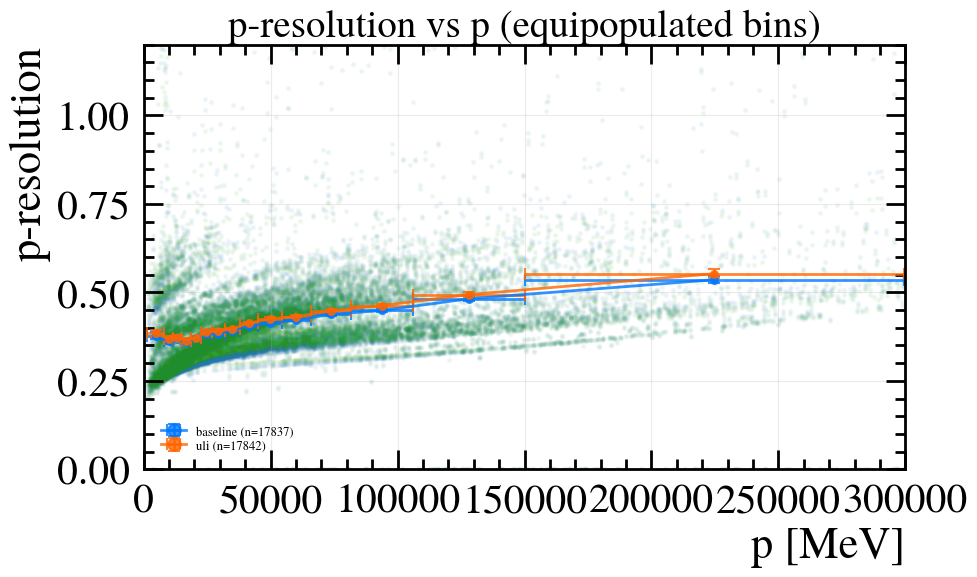

In [162]:
import numpy as np
import matplotlib.pyplot as plt

x_col = "p"
y_col = "fwd_pres_LastMeasurement"

x_min, x_max = 0.0, 300000.0
y_min, y_max = 0.0, 4.0
profile_n_bins = 15

# Build common equipopulated bin edges from baseline+uli after selection
all_x_for_binning = []
for name in ["baseline", "uli"]:
    tmp = dfs[name].copy()
    tmp["y_plot"] = 100.0 * tmp[y_col]
    mask_tmp = (
        np.isfinite(tmp[x_col])
        & np.isfinite(tmp["y_plot"])
        & (tmp[x_col] >= x_min)
        & (tmp[x_col] <= x_max)
        & (tmp["y_plot"] >= y_min)
        & (tmp["y_plot"] < y_max)
    )
    all_x_for_binning.append(tmp.loc[mask_tmp, x_col].to_numpy())

all_x = np.concatenate(all_x_for_binning)
quantiles = np.linspace(0.0, 1.0, profile_n_bins + 1)
profile_edges = np.quantile(all_x, quantiles)
profile_edges = np.unique(profile_edges)

if len(profile_edges) < 2:
    raise ValueError("Not enough distinct p values to build profile bins.")

profile_centers = 0.5 * (profile_edges[:-1] + profile_edges[1:])
profile_bin_widths = (profile_edges[1:] - profile_edges[:-1]) / 2.0  # Half-width for xerr
n_effective_bins = len(profile_edges) - 1
print(f"Using {n_effective_bins} equipopulated bins in p from {x_min:.0f} to {x_max:.0f}")

plt.figure(figsize=(10, 6))

for name, color in [("baseline", "tab:blue"), ("uli", "tab:green")]:
    df_sel = dfs[name].copy()
    df_sel["y_plot"] = 100.0 * df_sel[y_col]

    mask = (
        np.isfinite(df_sel[x_col])
        & np.isfinite(df_sel["y_plot"])
        & (df_sel[x_col] >= x_min)
        & (df_sel[x_col] <= x_max)
        & (df_sel["y_plot"] >= y_min)
        & (df_sel["y_plot"] < y_max)
    )
    df_sel = df_sel[mask]

    # Plot underlying scatter with low alpha
    plt.scatter(
        df_sel[x_col],
        df_sel["y_plot"],
        s=4,
        alpha=0.05,
        color=color,
        rasterized=True,
    )

    x_vals = df_sel[x_col].to_numpy()
    y_vals = df_sel["y_plot"].to_numpy()
    bin_idx = np.digitize(x_vals, profile_edges) - 1
    in_range = (bin_idx >= 0) & (bin_idx < n_effective_bins)

    counts = np.bincount(bin_idx[in_range], minlength=n_effective_bins)
    sums = np.bincount(bin_idx[in_range], weights=y_vals[in_range], minlength=n_effective_bins)
    sq_sums = np.bincount(bin_idx[in_range], weights=y_vals[in_range]**2, minlength=n_effective_bins)
    
    profile_mean = np.divide(
        sums,
        counts,
        out=np.full(n_effective_bins, np.nan, dtype=float),
        where=counts > 0,
    )
    
    # Compute standard error on the mean (1-sigma of the average)
    profile_var = np.divide(
        sq_sums - sums**2 / counts,
        counts,
        out=np.full(n_effective_bins, np.nan, dtype=float),
        where=counts > 0,
    )
    profile_std = np.sqrt(np.maximum(profile_var, 0))  # Standard deviation
    profile_std_err = profile_std / np.sqrt(np.maximum(counts, 1))  # Standard error on mean

    valid_bins = counts > 0
    print(f"{name}: non-empty profile bins = {int(valid_bins.sum())}/{n_effective_bins}")

    plt.errorbar(
        profile_centers[valid_bins],
        profile_mean[valid_bins],
        xerr=profile_bin_widths[valid_bins],
        yerr=profile_std_err[valid_bins],
        marker="o",
        linewidth=2,
        markersize=5,
        capsize=4,
        capthick=1.5,
        # color=color,
        label=f"{name} (n={len(df_sel)})",
        alpha=0.8,
    )

plt.xlabel("p [MeV]")
plt.ylabel("p-resolution")
plt.title("p-resolution vs p (equipopulated bins)")
plt.xlim(x_min, x_max)
plt.ylim(y_min, 1.2)
plt.grid(alpha=0.25)
plt.legend(markerscale=1.8, fontsize=9)
plt.tight_layout()
plt.show()

sigmaX - baseline: non-empty profile bins = 15/15
sigmaX - uli: non-empty profile bins = 15/15
sigmaY - baseline: non-empty profile bins = 15/15
sigmaY - uli: non-empty profile bins = 15/15
sigmaTX - baseline: non-empty profile bins = 15/15
sigmaTX - uli: non-empty profile bins = 15/15
sigmaTY - baseline: non-empty profile bins = 15/15
sigmaTY - uli: non-empty profile bins = 15/15


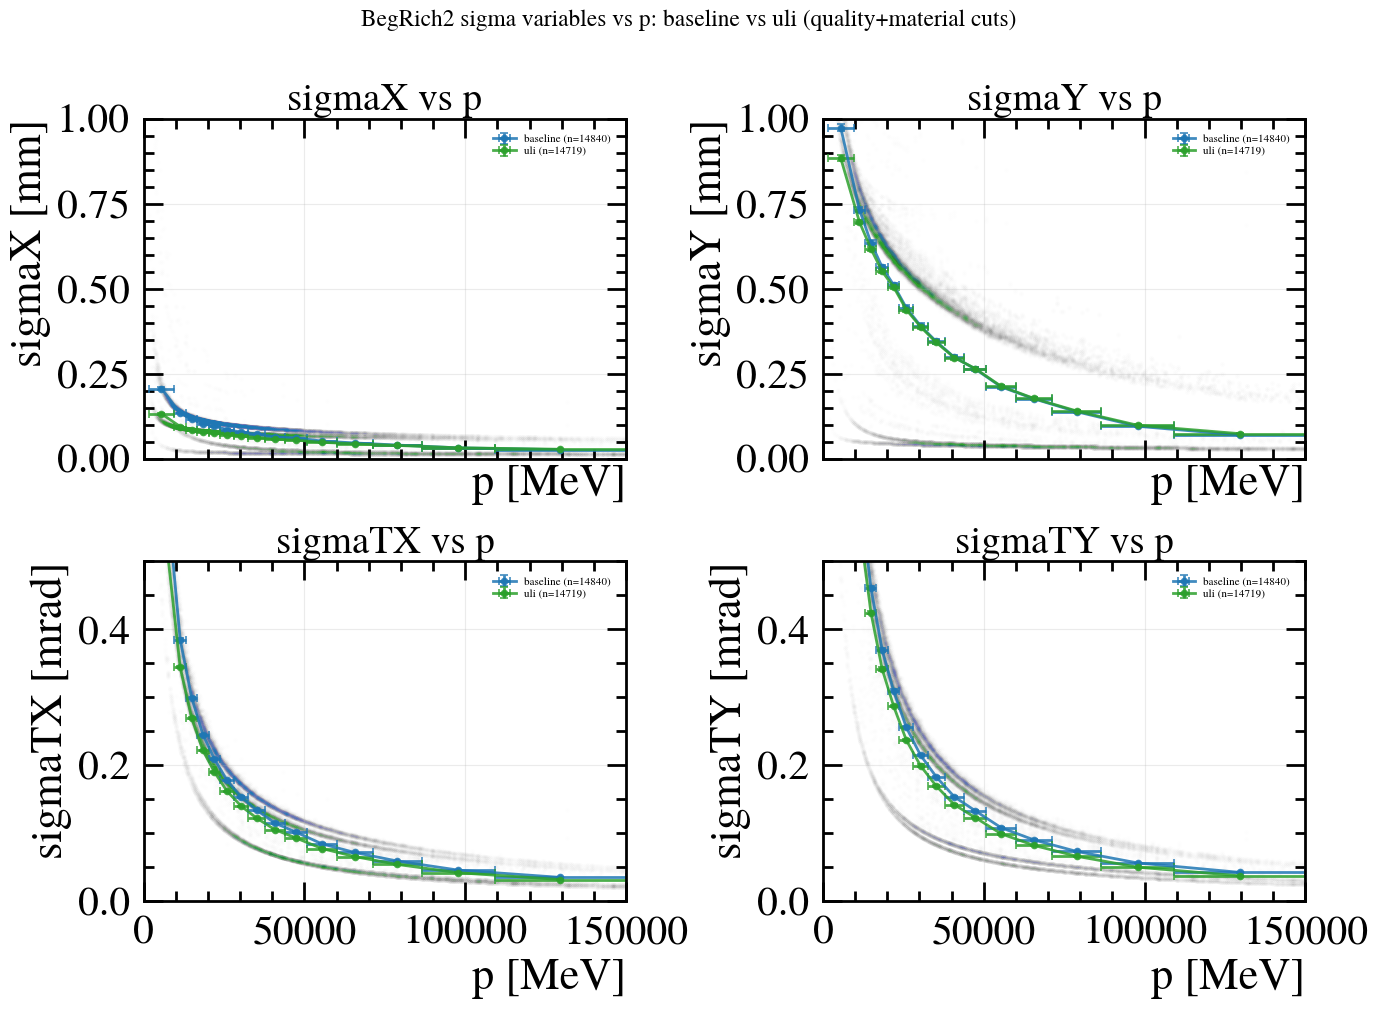

In [176]:
import numpy as np
import matplotlib.pyplot as plt

x_col = "p"
x_min, x_max = 0.0, 150000.0
profile_n_bins = 15

# (label, column_name)
vars_to_plot = [
    ("sigmaX", "fwd_sigmaX_BegRich2"),
    ("sigmaY", "fwd_sigmaY_BegRich2"),
    ("sigmaTX", "fwd_sigmaTX_BegRich2"),
    ("sigmaTY", "fwd_sigmaTY_BegRich2"),
]

# Plot conventions per variable: scale and y-range
plot_cfg = {
    "sigmaX": {"scale": 1.0, "ylim": (0.0, 1.0), "unit": "mm"},
    "sigmaY": {"scale": 1.0, "ylim": (0.0, 1.0), "unit": "mm"},
    "sigmaTX": {"scale": 1000.0, "ylim": (0.0, 0.5), "unit": "mrad"},
    "sigmaTY": {"scale": 1000.0, "ylim": (0.0, 0.5), "unit": "mrad"},
}

# Track-quality and material cuts requested by user
# (nMP*2 + nFT) >= 6, nVelo >= 6, and material at BegRich2 < 400
cut_cols = ["nMP", "nFT", "nVelo", "fwd_integrated_matbudget_BegRich2"]

# Validate requested columns
missing_cols = [c for _, c in vars_to_plot if c not in dfs["baseline"].columns or c not in dfs["uli"].columns]
missing_cut_cols = [c for c in cut_cols if c not in dfs["baseline"].columns or c not in dfs["uli"].columns]
if missing_cols or missing_cut_cols:
    raise KeyError(f"Missing columns: vars={missing_cols}, cuts={missing_cut_cols}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.ravel()

for ax, (label, y_col) in zip(axes, vars_to_plot):
    cfg = plot_cfg[label]
    y_scale = cfg["scale"]

    # Build common equipopulated bin edges from baseline+uli for this variable after cuts
    all_x_for_binning = []
    for name in ["baseline", "uli"]:
        tmp = dfs[name]
        cut_mask = (
            np.isfinite(tmp["nMP"])
            & np.isfinite(tmp["nFT"])
            & np.isfinite(tmp["nVelo"])
            & np.isfinite(tmp["fwd_integrated_matbudget_BegRich2"])
            & ((2.0 * tmp["nMP"] + tmp["nFT"]) >= 6)
            & (tmp["nVelo"] >= 6)
            & (tmp["fwd_integrated_matbudget_BegRich2"] < 400)
        )
        mask_tmp = (
            cut_mask
            & np.isfinite(tmp[x_col])
            & np.isfinite(tmp[y_col])
            & (tmp[x_col] >= x_min)
            & (tmp[x_col] <= x_max)
        )
        all_x_for_binning.append(tmp.loc[mask_tmp, x_col].to_numpy())

    all_x = np.concatenate(all_x_for_binning)
    if len(all_x) == 0:
        ax.text(0.5, 0.5, f"No entries after cuts for {label}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{label} vs p")
        continue

    profile_edges = np.quantile(all_x, np.linspace(0.0, 1.0, profile_n_bins + 1))
    profile_edges = np.unique(profile_edges)

    if len(profile_edges) < 2:
        ax.text(0.5, 0.5, f"Not enough distinct p values for {label}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{label} vs p")
        continue

    n_effective_bins = len(profile_edges) - 1
    profile_centers = 0.5 * (profile_edges[:-1] + profile_edges[1:])
    profile_bin_widths = 0.5 * (profile_edges[1:] - profile_edges[:-1])

    for name, color in [("baseline", "tab:blue"), ("uli", "tab:green")]:
        df_sel = dfs[name]
        cut_mask = (
            np.isfinite(df_sel["nMP"])
            & np.isfinite(df_sel["nFT"])
            & np.isfinite(df_sel["nVelo"])
            & np.isfinite(df_sel["fwd_integrated_matbudget_BegRich2"])
            & ((2.0 * df_sel["nMP"] + df_sel["nFT"]) >= 6)
            & (df_sel["nVelo"] >= 6)
            & (df_sel["fwd_integrated_matbudget_BegRich2"] < 400)
        )
        mask = (
            cut_mask
            & np.isfinite(df_sel[x_col])
            & np.isfinite(df_sel[y_col])
            & (df_sel[x_col] >= x_min)
            & (df_sel[x_col] <= x_max)
        )

        x_vals = df_sel.loc[mask, x_col].to_numpy()
        y_vals = y_scale * df_sel.loc[mask, y_col].to_numpy()

        # Underlying scatter
        ax.scatter(
            x_vals,
            y_vals,
            s=4,
            alpha=0.005,
            color=color,
            rasterized=True,
            # label = f"{name} scatter"
        )

        # Profiled mean and 1-sigma on mean
        bin_idx = np.digitize(x_vals, profile_edges) - 1
        in_range = (bin_idx >= 0) & (bin_idx < n_effective_bins)

        counts = np.bincount(bin_idx[in_range], minlength=n_effective_bins)
        sums = np.bincount(bin_idx[in_range], weights=y_vals[in_range], minlength=n_effective_bins)
        sq_sums = np.bincount(bin_idx[in_range], weights=y_vals[in_range] ** 2, minlength=n_effective_bins)

        profile_mean = np.divide(
            sums,
            counts,
            out=np.full(n_effective_bins, np.nan, dtype=float),
            where=counts > 0,
        )

        profile_var = np.divide(
            sq_sums - sums**2 / counts,
            counts,
            out=np.full(n_effective_bins, np.nan, dtype=float),
            where=counts > 0,
        )
        profile_std = np.sqrt(np.maximum(profile_var, 0.0))
        profile_std_err = profile_std / np.sqrt(np.maximum(counts, 1))

        valid_bins = counts > 0
        print(f"{label} - {name}: non-empty profile bins = {int(valid_bins.sum())}/{n_effective_bins}")

        ax.errorbar(
            profile_centers[valid_bins],
            profile_mean[valid_bins],
            xerr=profile_bin_widths[valid_bins],
            yerr=profile_std_err[valid_bins],
            marker="o",
            linewidth=2,
            markersize=4,
            capsize=3,
            capthick=1.2,
            # The line `color=color` in the code snippet you provided is setting the color of the scatter plot markers and error bars for each dataset being plotted. The `color` variable is assigned a specific color value based on the dataset being plotted (either "tab:blue" for baseline or "tab:green" for uli) in the loop iteration. This allows for distinguishing between the two datasets visually in the plot by using different colors for each dataset's data points and error bars.
            # The line `color=color` in the code snippet you provided is setting the color of the scatter plot markers and error bars for each dataset being plotted. The `color` variable is assigned a specific color value based on the dataset being plotted (either "tab:blue" for baseline or "tab:green" for uli) in the loop iteration. This allows for distinguishing between the two datasets visually in the plot by using different colors for each dataset's data points and error bars.
            color=color,
            label=f"{name} (n={len(x_vals)})",
            alpha=0.85,
        )

    ax.set_title(f"{label} vs p")
    ax.set_xlabel("p [MeV]")
    ax.set_ylabel(f"{label} [{cfg['unit']}]")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(*cfg["ylim"])
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.suptitle("BegRich2 sigma variables vs p: baseline vs uli (quality+material cuts)", y=1.01)
plt.tight_layout()
plt.show()

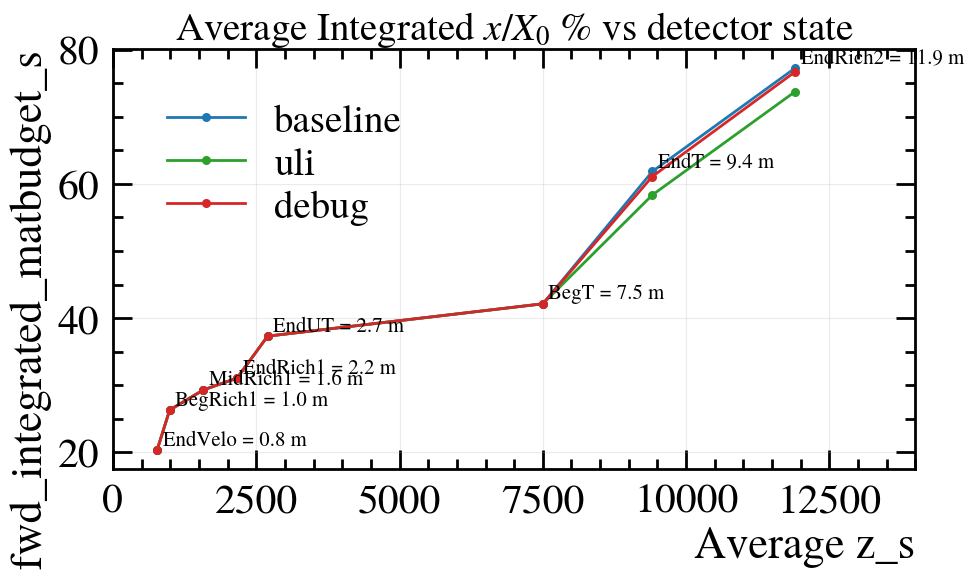

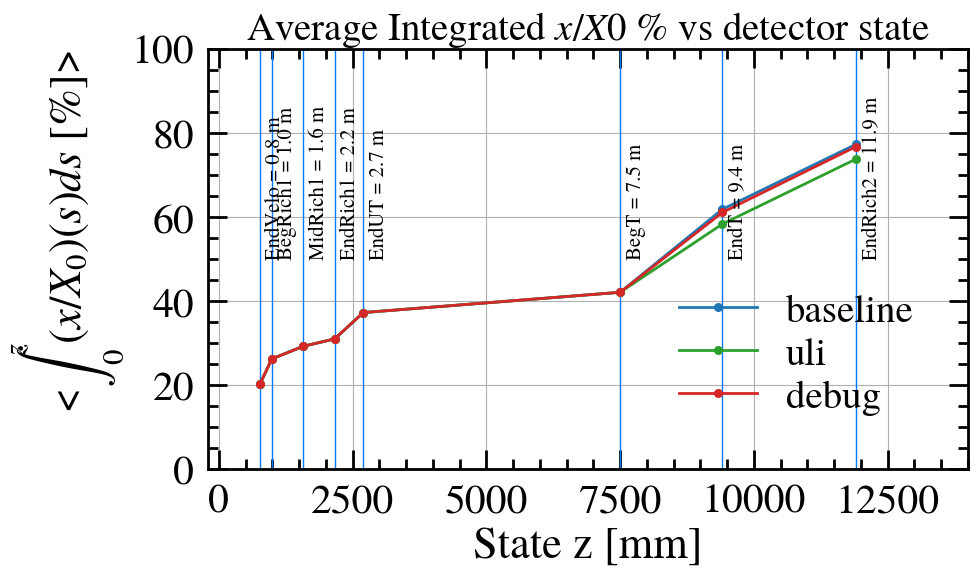

In [164]:
import matplotlib.pyplot as plt
# Average z_s (x-axis) vs average fwd_integrated_matbudget_s (y-axis)
# with per-state preselection: fwd_integrated_matbudget_s < 200
plt.figure(figsize=(10, 6))
import mplhep as hep
hep.style.use("LHCb2")
states_ordered = [ "EndVelo", "BegRich1", "MidRich1", "EndRich1", "EndUT", "BegT","EndT" , "EndRich2"] #"EndT",   "BegRich2", "EndRich2" ]
idx = 0
dfs = get_dfs()
# for name, color in [("debug", "tab:red")]:

for name, color in [("baseline", "tab:blue"), ("uli", "tab:green"), ("debug", "tab:red")]:
    mean_z = []
    mean_mat = []

    for s in states_ordered:
        mat_col = f"fwd_integrated_matbudget_{s}"
        z_col = f"z_{s}"
        df_pre = dfs[name][dfs[name][mat_col] < 200]
        mean_z.append(df_pre[z_col].mean())
        mean_mat.append(df_pre[mat_col].mean())

    plt.plot(
        mean_z,
        mean_mat,
        marker="o",
        linewidth=2,
        markersize=5,
        color=color,
        label=name,
    )
    if idx == 0 :        
        j = 0
        for x, y, s in zip(mean_z, mean_mat, states_ordered):                        
            plt.axvline(x = x, linewidth=1)
            plt.annotate(f"{s} = {x/1000:.1f} m", (x, 50), textcoords="offset points", xytext=(4,4), fontsize=15, color='black', rotation=90)
    idx+=1
plt.xlabel("State z [mm]", loc='center')
plt.ylabel(r"<$\int_{0}^{z} (x/X_{0})(s) ds$ [%]>")
plt.title(r"Average Integrated $x/X0$ % vs detector state")
plt.grid(alpha=1.0)
plt.xlim(-200, 14000)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

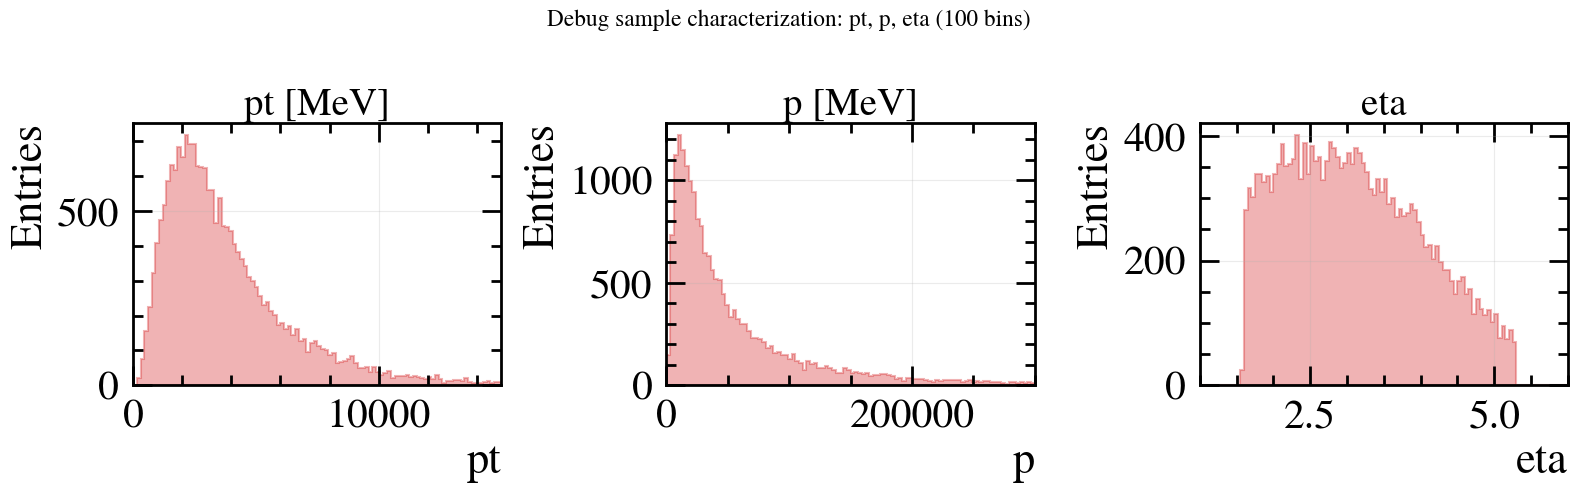


Summary stats in requested ranges (debug):
pt: n=19765, mean=3801.969, std=2528.798, median=3141.158, p1=557.959, p99=12440.293
p: n=19568, mean=53984.281, std=55343.449, median=33685.301, p1=3288.677, p99=259552.828
eta: n=19973, mean=3.108, std=0.931, median=3.023, p1=1.629, p99=5.170


In [138]:
import numpy as np
import matplotlib.pyplot as plt

df_debug = dfs["debug"].copy()

vars_to_plot = ["pt", "p", "eta"]
range_map = {
    "pt": (0.0, 15000.0),
    "p": (0.0, 300000.0),
    "eta": (1.0, 6.0),
}
n_bins = 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

for ax, v in zip(axes, vars_to_plot):
    vals = df_debug[v].to_numpy()
    vals = vals[np.isfinite(vals)]

    ax.hist(
        vals,
        bins=n_bins,
        range=range_map[v],
        histtype="stepfilled",
        alpha=0.35,
        color="tab:red",
        edgecolor="tab:red",
        linewidth=1.5,
    )

    ax.set_title(f"{v} [{ 'MeV' if v in ['pt', 'p'] else '' }]".replace(" []", ""))
    ax.set_xlabel(v)
    ax.set_ylabel("Entries")
    ax.set_xlim(*range_map[v])
    ax.grid(alpha=0.25)

plt.suptitle(f"Debug sample characterization: pt, p, eta ({n_bins} bins)", y=1.03)
plt.tight_layout()
plt.show()

print("\nSummary stats in requested ranges (debug):")
for v in vars_to_plot:
    low, high = range_map[v]
    s = df_debug[v]
    s = s[np.isfinite(s) & (s >= low) & (s <= high)]
    print(
        f"{v}: n={len(s)}, mean={s.mean():.3f}, std={s.std():.3f}, "
        f"median={s.median():.3f}, p1={s.quantile(0.01):.3f}, p99={s.quantile(0.99):.3f}"
    )

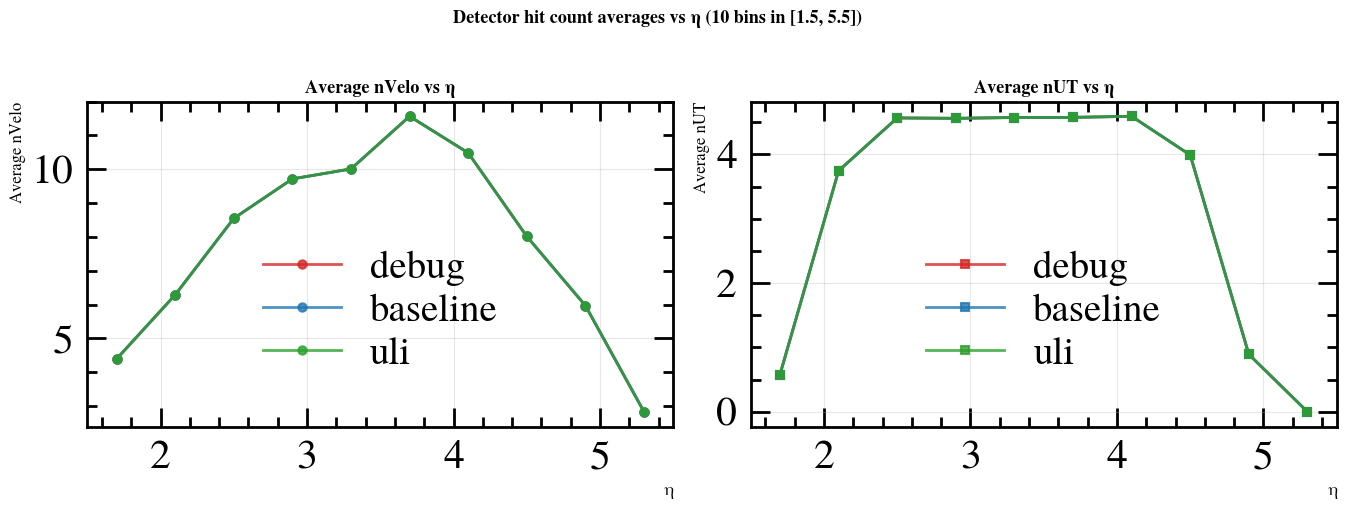


Average nVelo and nUT per η bin:
η bin                Debug nVelo     Baseline nVelo  Uli nVelo      
-----------------------------------------------------------------
[1.50, 1.90)         4.391           4.391           4.391          
[1.90, 2.30)         6.287           6.287           6.287          
[2.30, 2.70)         8.547           8.547           8.547          
[2.70, 3.10)         9.714           9.714           9.714          
[3.10, 3.50)         10.009          10.009          10.009         
[3.50, 3.90)         11.564          11.564          11.564         
[3.90, 4.30)         10.484          10.484          10.484         
[4.30, 4.70)         8.014           8.014           8.014          
[4.70, 5.10)         5.969           5.969           5.969          
[5.10, 5.50)         2.831           2.831           2.831          

η bin                Debug nUT       Baseline nUT    Uli nUT        
-----------------------------------------------------------------
[1.50

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define eta binning (consistent with previous plots)
eta_min, eta_max = 1.5, 5.5
n_eta_bins = 10
eta_edges = np.linspace(eta_min, eta_max, n_eta_bins + 1)
eta_centers = (eta_edges[:-1] + eta_edges[1:]) / 2

# Create figure with two panels (nVelo and nUT)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Color map for samples
color_map = {"debug": "tab:red", "baseline": "tab:blue", "uli": "tab:green"}

# Process each sample
for name, color in color_map.items():
    df_sample = dfs[name]
    
    # Filter to eta range
    df_eta = df_sample[(df_sample["eta"] >= eta_min) & (df_sample["eta"] <= eta_max)]
    
    if len(df_eta) > 0:
        # Bin by eta
        eta_binned = pd.cut(df_eta["eta"], bins=eta_edges)
        
        # Compute averages per bin
        avg_nVelo = df_eta.groupby(eta_binned)["nVelo"].mean()
        avg_nUT = df_eta.groupby(eta_binned)["nUT"].mean()
        
        # Plot nVelo
        ax1.plot(
            eta_centers,
            avg_nVelo.values,
            marker="o",
            linestyle="-",
            linewidth=2,
            markersize=6,
            color=color,
            label=name,
            alpha=0.8,
        )
        
        # Plot nUT
        ax2.plot(
            eta_centers,
            avg_nUT.values,
            marker="s",
            linestyle="-",
            linewidth=2,
            markersize=6,
            color=color,
            label=name,
            alpha=0.8,
        )

# Configure nVelo panel
ax1.set_xlabel("η", fontsize=12)
ax1.set_ylabel("Average nVelo", fontsize=12)
ax1.set_title("Average nVelo vs η", fontsize=13, fontweight="bold")
ax1.grid(alpha=0.3)
ax1.legend()
ax1.set_xlim(eta_min, eta_max)

# Configure nUT panel
ax2.set_xlabel("η", fontsize=12)
ax2.set_ylabel("Average nUT", fontsize=12)
ax2.set_title("Average nUT vs η", fontsize=13, fontweight="bold")
ax2.grid(alpha=0.3)
ax2.legend()
ax2.set_xlim(eta_min, eta_max)

plt.suptitle(f"Detector hit count averages vs η ({n_eta_bins} bins in [{eta_min}, {eta_max}])", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nAverage nVelo and nUT per η bin:")
print(f"{'η bin':<20} {'Debug nVelo':<15} {'Baseline nVelo':<15} {'Uli nVelo':<15}")
print("-" * 65)

for i, (e_low, e_high) in enumerate(zip(eta_edges[:-1], eta_edges[1:])):
    eta_range = f"[{e_low:.2f}, {e_high:.2f})"
    vals = []
    for name in ["debug", "baseline", "uli"]:
        df_sample = dfs[name]
        df_eta = df_sample[(df_sample["eta"] >= e_low) & (df_sample["eta"] < e_high)]
        vals.append(df_eta["nVelo"].mean() if len(df_eta) > 0 else np.nan)
    print(f"{eta_range:<20} {vals[0]:<15.3f} {vals[1]:<15.3f} {vals[2]:<15.3f}")

print(f"\n{'η bin':<20} {'Debug nUT':<15} {'Baseline nUT':<15} {'Uli nUT':<15}")
print("-" * 65)

for i, (e_low, e_high) in enumerate(zip(eta_edges[:-1], eta_edges[1:])):
    eta_range = f"[{e_low:.2f}, {e_high:.2f})"
    vals = []
    for name in ["debug", "baseline", "uli"]:
        df_sample = dfs[name]
        df_eta = df_sample[(df_sample["eta"] >= e_low) & (df_sample["eta"] < e_high)]
        vals.append(df_eta["nUT"].mean() if len(df_eta) > 0 else np.nan)
    print(f"{eta_range:<20} {vals[0]:<15.3f} {vals[1]:<15.3f} {vals[2]:<15.3f}")